 @author ; Dhruv Thumar


In [1]:
# fetching data from uci repo

import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score



In [2]:

COLUMNS = [
    "a1","a2","a3","a4","a5","a6",
    "b1","b2","b3","b4","b5","b6",
    "c1","c2","c3","c4","c5","c6",
    "d1","d2","d3","d4","d5","d6",
    "e1","e2","e3","e4","e5","e6",
    "f1","f2","f3","f4","f5","f6",
    "g1","g2","g3","g4","g5","g6",
    "class"
]

dataset = fetch_ucirepo(id=26)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
df.columns = COLUMNS

df.to_csv("dataset/connect4_uci.csv", index=False)

print(f"Loaded {len(df)} rows")
print(df["class"].value_counts())
print(df.head(3))

Loaded 67557 rows
class
win     44473
loss    16635
draw     6449
Name: count, dtype: int64
  a1 a2 a3 a4 a5 a6 b1 b2 b3 b4  ... f4 f5 f6 g1 g2 g3 g4 g5 g6 class
0  b  b  b  b  b  b  b  b  b  b  ...  b  b  b  b  b  b  b  b  b   win
1  b  b  b  b  b  b  b  b  b  b  ...  b  b  b  b  b  b  b  b  b   win
2  b  b  b  b  b  b  o  b  b  b  ...  b  b  b  b  b  b  b  b  b   win

[3 rows x 43 columns]


# Data PreProcessing

In [3]:
df = pd.read_csv("dataset/connect4_uci.csv")
print(df.shape)
print(df.head(3))

(67557, 43)
  a1 a2 a3 a4 a5 a6 b1 b2 b3 b4  ... f4 f5 f6 g1 g2 g3 g4 g5 g6 class
0  b  b  b  b  b  b  b  b  b  b  ...  b  b  b  b  b  b  b  b  b   win
1  b  b  b  b  b  b  b  b  b  b  ...  b  b  b  b  b  b  b  b  b   win
2  b  b  b  b  b  b  o  b  b  b  ...  b  b  b  b  b  b  b  b  b   win

[3 rows x 43 columns]


In [4]:
feature_cols = [c for c in df.columns if c != "class"]
print(f"Feature columns : {len(feature_cols)}")
print(f"First 5         : {feature_cols[:5]}")
print(f"Last 5          : {feature_cols[-5:]}")

Feature columns : 42
First 5         : ['a1', 'a2', 'a3', 'a4', 'a5']
Last 5          : ['g2', 'g3', 'g4', 'g5', 'g6']


In [5]:
CELL_MAP = {"b": 0, "x": 1, "o": 2}

for col in feature_cols:
    df[col] = df[col].map(CELL_MAP)

print(df[feature_cols].head(3))

   a1  a2  a3  a4  a5  a6  b1  b2  b3  b4  ...  f3  f4  f5  f6  g1  g2  g3  \
0   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
1   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
2   0   0   0   0   0   0   2   0   0   0  ...   0   0   0   0   0   0   0   

   g4  g5  g6  
0   0   0   0  
1   0   0   0  
2   0   0   0  

[3 rows x 42 columns]


now converting text values b, x, o into numbers 0, 1, 2 as the model can't learn from text, but only numbers

In [6]:

le = LabelEncoder()
df["label"] = le.fit_transform(df["class"])

print(f"Classes : {list(le.classes_)}")
print(df[["class", "label"]].head(10))

Classes : ['draw', 'loss', 'win']
  class  label
0   win      2
1   win      2
2   win      2
3   win      2
4   win      2
5   win      2
6  draw      0
7   win      2
8   win      2
9   win      2


LabelEncoder converts draw, loss, win into numbers 0, 1, 2 alphabetically

In [7]:
X = df[feature_cols].values
y = df["label"].values

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Sample X: {X[0]}")
print(f"Sample y: {y[0]}")

X shape : (67557, 42)
y shape : (67557,)
Sample X: [0 0 0 0 0 0 0 0 0 0 0 0 1 2 0 0 0 0 1 2 1 2 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0]
Sample y: 2


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {len(X_train)} rows")
print(f"Test  : {len(X_test)} rows")

Train : 54045 rows
Test  : 13512 rows


test_size= 0.2 means 80% of data trains the model and 20% is saved to test it on boards it has never seen

# Training the model

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model ready!")
print(model)

print("Training complete!")
print(f"Trees trained : {model.n_estimators}")

Model ready!
RandomForestClassifier(n_jobs=-1, random_state=42)
Training complete!
Trees trained : 100


In [10]:
y_pred = model.predict(X_test)

print(f"First 50 predictions : {y_pred[:50]}")
print(f"First 50 actual      : {y_test[:50]}")

First 50 predictions : [1 2 2 0 1 2 2 2 2 2 2 1 2 2 2 2 1 2 2 2 2 2 2 2 1 1 1 2 1 2 2 2 2 2 2 2 1
 1 2 2 1 2 2 1 2 2 1 2 2 2]
First 50 actual      : [1 2 2 2 1 2 2 2 2 2 2 1 2 2 2 2 0 2 2 2 2 2 2 2 1 1 1 1 1 2 2 2 2 2 2 2 1
 1 1 2 2 2 2 1 2 2 1 0 2 2]


# Evaluation

In [11]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 82.59%


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        draw       0.56      0.16      0.24      1290
        loss       0.81      0.73      0.77      3327
         win       0.84      0.96      0.90      8895

    accuracy                           0.83     13512
   macro avg       0.74      0.62      0.64     13512
weighted avg       0.81      0.83      0.80     13512



we see the draw performs worst because it only has 9.5% of the data — the model hasn't seen enough draw examples to learn them well

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 202  277  811]
 [  83 2439  805]
 [  75  301 8519]]


draw is the worst — only 202 out of 1290 draws predicted correctly, most get misclassified as win
win is the best — 8519 out of 8895 correct

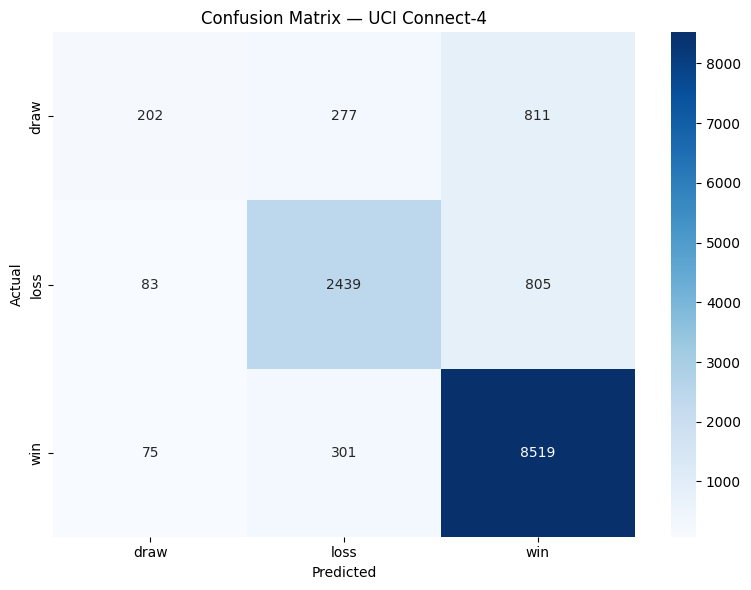

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix — UCI Connect-4")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("report/confusion_matrix.png", dpi=150)
plt.show()

The darker the blue, the more predictions landed there — diagonal is darkest meaning most predictions are correct